# 08 — CitySeer Network Accessibility (Phase 3)

Computes walking-distance accessibility from every building entrance to:
- **Parks** (77 polygons, 400m + 800m)
- **Public transport stops** (bus, metro, train — 400m + 800m)
- **Cycling infrastructure** (existing paths only, 400m)

## Approach

1. Load the existing processed pedestrian network (GeoPackage edges, EPSG:25832)
2. Build a CitySeer graph: clean → decompose (20m segments) → convert primal → dual
3. POIs as polygons throughout (parks as-is; cycling lines get 2m buffer)
4. Compute `layers.compute_accessibilities` on the dual network
5. Join node-level metrics back to entrance points via `sjoin_nearest`
6. Write `entrances_accessibility` layer to the integrated buildings GeoPackage

The dual graph representation (street segments as nodes) is CitySeer's preferred format
for leveraging its RUST-powered computation engine.

**Output**: `data/integrated/norrebro_buildings.gpkg` → layer `entrances_accessibility`

In [ ]:
import sys
from pathlib import Path

project_root = Path("..").resolve()
sys.path.insert(0, str(project_root))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from cityseer.tools import io, graphs
from cityseer.metrics import layers

from src.utils.config import (
    PEDESTRIAN_NETWORK_GPKG,
    PEDESTRIAN_NETWORK_GRAPHML,
    GREENSPACES_OUTPUT,
    TRANSPORT_STOPS_OUTPUT,
    CYCLING_OUTPUT,
    INTEGRATED_BUILDINGS,
    ENTRANCES_DEMOGRAPHICS_LAYER,
    ENTRANCES_ACCESSIBILITY_LAYER,
    NORREBRO_BOUNDARY_FILE,
    NORREBRO_BOUNDARY_LAYER,
    WALKING_SPEED,
    MAX_WALK_DISTANCE,
)

print("CitySeer and dependencies loaded")
print(f"Network source: {PEDESTRIAN_NETWORK_GPKG}")
print(f"Walking speed: {WALKING_SPEED} m/s | Max walk distance: {MAX_WALK_DISTANCE} m")

## 1. Build CitySeer Network

Pipeline: load GeoPackage edges → explode multipart → build primal graph →
clean (filler + dangling nodes) → decompose to 20m segments → convert to dual

In [6]:
# Load edges from processed GeoPackage (already EPSG:25832)
gdf_edges = gpd.read_file(PEDESTRIAN_NETWORK_GPKG, layer="edges")
print(f"Edges loaded: {len(gdf_edges):,} | CRS: {gdf_edges.crs}")
print(f"Geometry types: {gdf_edges.geometry.geom_type.value_counts().to_dict()}")

# Explode multipart geometries to single LineStrings
gdf_edges = gdf_edges.explode(index_parts=False)
gdf_edges = gdf_edges.reset_index(drop=True)
print(f"After explode: {len(gdf_edges):,} edges")

Edges loaded: 15,058 | CRS: EPSG:25832
Geometry types: {'LineString': 15058}
After explode: 15,058 edges


In [7]:
# Build primal graph from GeoDataFrame
# Fallback if this fails: load GraphML with osmnx then io.nx_from_osm_nx(G_osm)
G = io.nx_from_generic_geopandas(gdf_edges)
print(f"Primal graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

# Basic cleaning
G = graphs.nx_remove_filler_nodes(G)  # remove degree-2 nodes (straightens edges)
print(
    f"After remove_filler_nodes: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges"
)

# Decompose into ~20m segments for fine-grained distance resolution
G = graphs.nx_decompose(G, decompose_max=20)
print(
    f"After decompose(20m): {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges"
)

# Convert primal → dual (street segments become nodes)
G_dual = graphs.nx_to_dual(G)
print(
    f"Dual graph: {G_dual.number_of_nodes():,} nodes, {G_dual.number_of_edges():,} edges"
)

# Extract network structure
nodes_gdf, edges_gdf_dual, network_structure = io.network_structure_from_nx(G_dual)
print(f"\nnetwork_structure built")
print(f"nodes_gdf: {len(nodes_gdf):,} rows | CRS: {nodes_gdf.crs}")
print(f"edges_gdf_dual: {len(edges_gdf_dual):,} rows")

100%|██████████| 15058/15058 [00:00<00:00, 16524.88it/s]
INFO:cityseer.tools.graphs:Merging parallel edges within buffer of 1.
100%|██████████| 15039/15039 [00:00<00:00, 324030.98it/s]
INFO:cityseer.tools.graphs:Removing filler nodes.


Primal graph: 10,435 nodes, 15,034 edges


100%|██████████| 10435/10435 [00:00<00:00, 791299.42it/s]
INFO:cityseer.tools.graphs:Decomposing graph to maximum edge lengths of 20.


After remove_filler_nodes: 10,295 nodes, 14,894 edges


100%|██████████| 14894/14894 [00:01<00:00, 10360.94it/s]
INFO:cityseer.tools.graphs:Converting graph to dual.


After decompose(20m): 29,455 nodes, 34,054 edges


INFO:cityseer.tools.graphs:Preparing dual nodes
100%|██████████| 34054/34054 [00:00<00:00, 146626.04it/s]
INFO:cityseer.tools.graphs:Preparing dual edges (splitting and welding geoms)
100%|██████████| 34054/34054 [00:07<00:00, 4404.22it/s]
INFO:cityseer.tools.io:Preparing node and edge arrays from networkX graph.


Dual graph: 34,054 nodes, 51,766 edges


100%|██████████| 34054/34054 [00:02<00:00, 15394.69it/s]
INFO:cityseer.graph:Edge R-tree built successfully with 51766 items.



network_structure built
nodes_gdf: 34,054 rows | CRS: PROJCRS["ETRS89 / UTM zone 32N",BASEGEOGCRS["ETRS89",ENSEMBLE["European Terrestrial Reference System 1989 ensemble",MEMBER["European Terrestrial Reference Frame 1989"],MEMBER["European Terrestrial Reference Frame 1990"],MEMBER["European Terrestrial Reference Frame 1991"],MEMBER["European Terrestrial Reference Frame 1992"],MEMBER["European Terrestrial Reference Frame 1993"],MEMBER["European Terrestrial Reference Frame 1994"],MEMBER["European Terrestrial Reference Frame 1996"],MEMBER["European Terrestrial Reference Frame 1997"],MEMBER["European Terrestrial Reference Frame 2000"],MEMBER["European Terrestrial Reference Frame 2005"],MEMBER["European Terrestrial Reference Frame 2014"],MEMBER["European Terrestrial Reference Frame 2020"],ELLIPSOID["GRS 1980",6378137,298.257222101,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[0.1]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4258]],CONVERSION["UTM zone 32N",METHOD["Tran

## 2. Validate Network

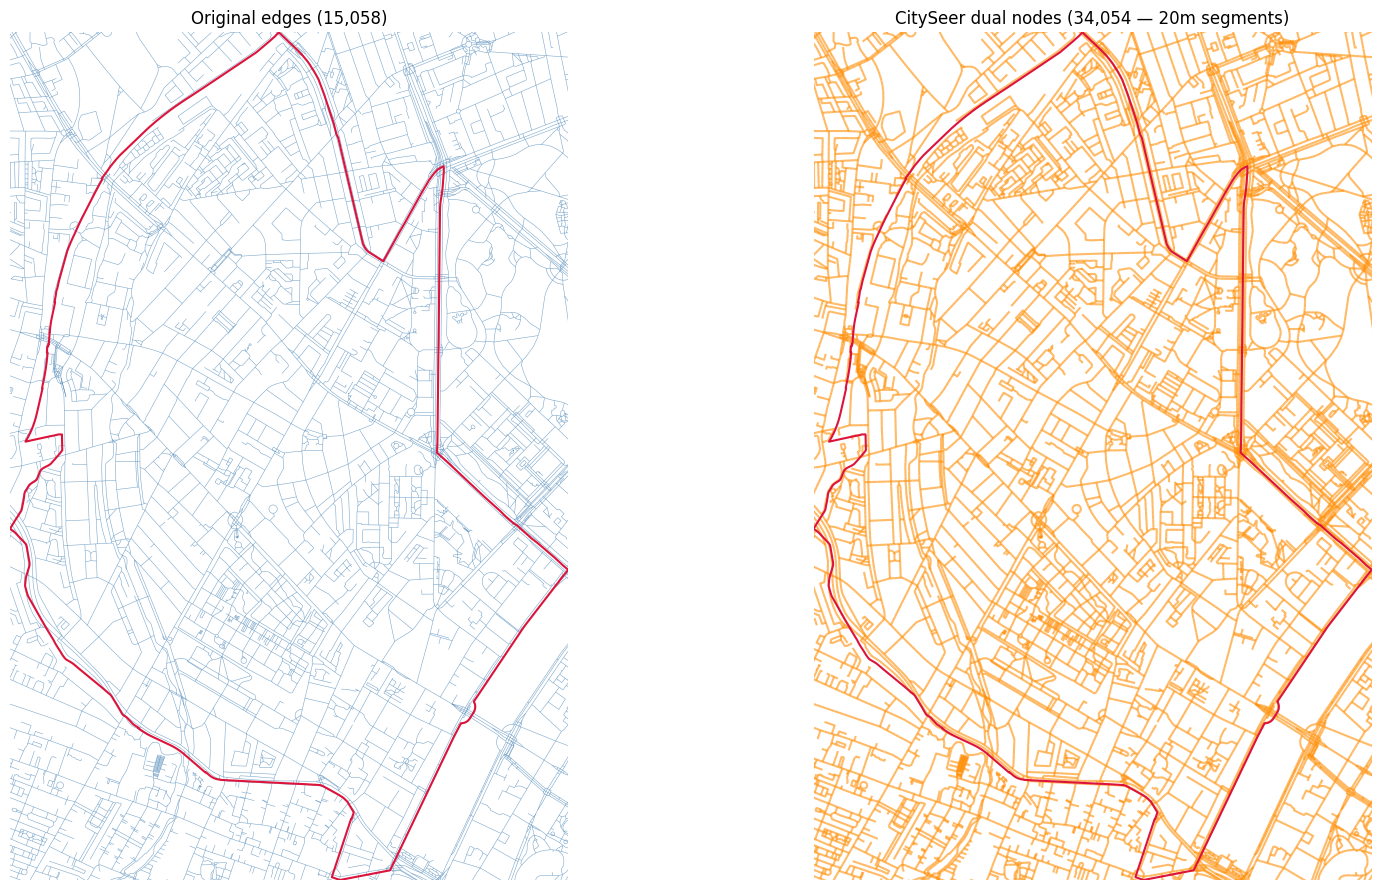

In [8]:
boundary = gpd.read_file(NORREBRO_BOUNDARY_FILE, layer=NORREBRO_BOUNDARY_LAYER)
bbox = boundary.total_bounds  # [minx, miny, maxx, maxy]

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Left: original GeoPackage edges
gdf_edges.plot(ax=axes[0], linewidth=0.4, color="steelblue", alpha=0.7)
boundary.boundary.plot(ax=axes[0], color="crimson", linewidth=1.5)
axes[0].set_xlim(bbox[0], bbox[2])
axes[0].set_ylim(bbox[1], bbox[3])
axes[0].set_title(f"Original edges ({len(gdf_edges):,})")
axes[0].set_axis_off()

# Right: CitySeer dual nodes (each = a street segment)
nodes_gdf.plot(ax=axes[1], markersize=1, color="darkorange", alpha=0.6)
boundary.boundary.plot(ax=axes[1], color="crimson", linewidth=1.5)
axes[1].set_xlim(bbox[0], bbox[2])
axes[1].set_ylim(bbox[1], bbox[3])
axes[1].set_title(f"CitySeer dual nodes ({len(nodes_gdf):,} — 20m segments)")
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 3. Prepare POIs

All POIs are passed as **polygons** so CitySeer computes distance to the nearest
boundary point (not centroid). Each category uses `data_id_col` for deduplication.

In [9]:
# --- Parks ---
parks = gpd.read_file(GREENSPACES_OUTPUT, layer="parks")
print(f"Parks loaded: {len(parks):,} features")
print(f"Geometry types: {parks.geometry.geom_type.value_counts().to_dict()}")
print(f"ID column (park_id): {parks['park_id'].nunique()} unique values")

# Explode MultiPolygon → Polygon, keep park_id for deduplication
parks = parks.explode(index_parts=False).reset_index(drop=True)
parks["poi_type"] = "park"
print(f"Parks after explode: {len(parks):,} polygons")

Parks loaded: 77 features
Geometry types: {'MultiPolygon': 77}
ID column (park_id): 59 unique values
Parks after explode: 121 polygons


In [10]:
# --- Transit Stops ---
stops = gpd.read_file(TRANSPORT_STOPS_OUTPUT, layer="stops")
print(f"Stops loaded: {len(stops):,} features")
print(f"Mode breakdown: {stops['transport_mode'].value_counts().to_dict()}")
print(f"stop_id unique: {stops['stop_id'].nunique()}")

stops = stops.copy()
stops["poi_type"] = stops["transport_mode"]  # "bus" / "metro" / "train"

Stops loaded: 2,687 features
Mode breakdown: {'bus': 2581, 'train': 62, 'metro': 44}
stop_id unique: 2660


In [11]:
# --- Cycling Infrastructure ---
cycling = gpd.read_file(CYCLING_OUTPUT, layer="cykeldata")
print(f"Cycling loaded: {len(cycling):,} features")
print(f"Status values: {cycling['status'].value_counts().to_dict()}")
print(f"Geometry types: {cycling.geometry.geom_type.value_counts().to_dict()}")

# Filter to existing infrastructure only
cycling_existing = cycling[cycling["status"] == "Existing"].copy()
print(f"Existing cycling features: {len(cycling_existing):,}")

# Explode MultiLineString → LineString, then buffer 2m → thin polygon
# Use 'id' column for deduplication (one feature per street segment)
cycling_existing = cycling_existing.explode(index_parts=False).reset_index(drop=True)
cycling_existing["geometry"] = cycling_existing.geometry.buffer(2)
cycling_existing["poi_type"] = "cycling_infra"
print(f"Cycling after explode + 2m buffer: {len(cycling_existing):,} polygons")
print(f"id unique: {cycling_existing['id'].nunique()}")

Cycling loaded: 3,638 features
Status values: {'Existing': 3315, 'Planned': 296, 'Projected': 27}
Geometry types: {'MultiLineString': 3638}
Existing cycling features: 3,315
Cycling after explode + 2m buffer: 3,339 polygons
id unique: 3315


## 4. Compute Park Accessibility

In [12]:
print("Computing park accessibility (400m, 800m)...")
nodes_gdf, parks = layers.compute_accessibilities(
    data_gdf=parks,
    landuse_column_label="poi_type",
    accessibility_keys=["park"],
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=[400, 800],
    max_netw_assign_dist=100,
    speed_m_s=WALKING_SPEED,
    data_id_col="park_id",
)

park_cols = [c for c in nodes_gdf.columns if "park" in c]
print(f"\nPark accessibility columns added ({len(park_cols)}): {park_cols}")
print(nodes_gdf[park_cols].describe())

INFO:cityseer.metrics.layers:Computing land-use accessibility for: park
INFO:cityseer.metrics.layers:Assigning data to network.
INFO:cityseer.data:Assigning 121 data entries to network nodes (max_dist: 100).
INFO:cityseer.data:Finished assigning data. 3544 assignments added to 3285 nodes.


Computing park accessibility (400m, 800m)...


100%|██████████| 34054/34054 [00:02<00:00, 13552.49it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 400m, Beta: 0.01, Walking Time: 4.766666666666667 minutes.
INFO:cityseer.config:Distance: 800m, Beta: 0.005, Walking Time: 9.516666666666667 minutes.



Park accessibility columns added (5): ['cc_park_400_nw', 'cc_park_400_wt', 'cc_park_800_nw', 'cc_park_800_wt', 'cc_park_nearest_max_800']
       cc_park_400_nw  cc_park_400_wt  cc_park_800_nw  cc_park_800_wt  \
count    34054.000000    34054.000000    34054.000000    34054.000000   
mean         1.952428        0.389364        6.001233        0.951793   
std          1.433957        0.423723        3.659990        0.647442   
min          0.000000        0.000000        0.000000        0.000000   
25%          1.000000        0.048499        3.000000        0.456596   
50%          2.000000        0.232602        5.000000        0.875138   
75%          3.000000        0.622539        8.000000        1.372073   
max          7.000000        2.432822       18.000000        3.625749   

       cc_park_nearest_max_800  
count             32776.000000  
mean                211.053284  
std                 177.321636  
min                   0.000000  
25%                  72.660690  
50%  

## 5. Compute Transit Accessibility

In [13]:
print("Computing transit accessibility (bus, metro, train — 400m, 800m)...")
nodes_gdf, stops = layers.compute_accessibilities(
    data_gdf=stops,
    landuse_column_label="poi_type",
    accessibility_keys=["bus", "metro", "train"],
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=[400, 800],
    max_netw_assign_dist=100,
    speed_m_s=WALKING_SPEED,
    data_id_col="stop_id",
)

transit_cols = [
    c for c in nodes_gdf.columns if any(m in c for m in ["bus", "metro", "train"])
]
print(f"\nTransit accessibility columns added ({len(transit_cols)}):")
for col in transit_cols:
    non_null = nodes_gdf[col].notna().sum()
    print(f"  {col}: {non_null:,} non-null nodes")

INFO:cityseer.metrics.layers:Computing land-use accessibility for: bus, metro, train
INFO:cityseer.metrics.layers:Assigning data to network.
INFO:cityseer.data:Assigning 2687 data entries to network nodes (max_dist: 100).
INFO:cityseer.data:Finished assigning data. 513 assignments added to 455 nodes.


Computing transit accessibility (bus, metro, train — 400m, 800m)...


100%|██████████| 34054/34054 [00:02<00:00, 12402.97it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 400m, Beta: 0.01, Walking Time: 4.766666666666667 minutes.
INFO:cityseer.config:Distance: 800m, Beta: 0.005, Walking Time: 9.516666666666667 minutes.



Transit accessibility columns added (15):
  cc_bus_400_nw: 34,054 non-null nodes
  cc_bus_400_wt: 34,054 non-null nodes
  cc_bus_800_nw: 34,054 non-null nodes
  cc_bus_800_wt: 34,054 non-null nodes
  cc_bus_nearest_max_800: 33,882 non-null nodes
  cc_metro_400_nw: 34,054 non-null nodes
  cc_metro_400_wt: 34,054 non-null nodes
  cc_metro_800_nw: 34,054 non-null nodes
  cc_metro_800_wt: 34,054 non-null nodes
  cc_metro_nearest_max_800: 16,598 non-null nodes
  cc_train_400_nw: 34,054 non-null nodes
  cc_train_400_wt: 34,054 non-null nodes
  cc_train_800_nw: 34,054 non-null nodes
  cc_train_800_wt: 34,054 non-null nodes
  cc_train_nearest_max_800: 12,150 non-null nodes


## 6. Compute Cycling Accessibility

In [14]:
print("Computing cycling infrastructure accessibility (400m)...")
nodes_gdf, cycling_existing = layers.compute_accessibilities(
    data_gdf=cycling_existing,
    landuse_column_label="poi_type",
    accessibility_keys=["cycling_infra"],
    nodes_gdf=nodes_gdf,
    network_structure=network_structure,
    distances=[400],
    max_netw_assign_dist=100,
    speed_m_s=WALKING_SPEED,
    data_id_col="id",
)

cycling_cols = [c for c in nodes_gdf.columns if "cycling" in c]
print(f"\nCycling accessibility columns ({len(cycling_cols)}): {cycling_cols}")
print(nodes_gdf[cycling_cols].describe())

INFO:cityseer.metrics.layers:Computing land-use accessibility for: cycling_infra
INFO:cityseer.metrics.layers:Assigning data to network.
INFO:cityseer.data:Assigning 3339 data entries to network nodes (max_dist: 100).
INFO:cityseer.data:Finished assigning data. 17050 assignments added to 9488 nodes.


Computing cycling infrastructure accessibility (400m)...


100%|██████████| 34054/34054 [00:01<00:00, 22952.37it/s]
INFO:cityseer.config:Metrics computed for:
INFO:cityseer.config:Distance: 400m, Beta: 0.01, Walking Time: 4.766666666666667 minutes.



Cycling accessibility columns (3): ['cc_cycling_infra_400_nw', 'cc_cycling_infra_400_wt', 'cc_cycling_infra_nearest_max_400']
       cc_cycling_infra_400_nw  cc_cycling_infra_400_wt  \
count             34054.000000             34054.000000   
mean                 17.113907                 2.716094   
std                  10.485491                 2.236385   
min                   0.000000                 0.000000   
25%                   8.000000                 0.910918   
50%                  17.000000                 2.102129   
75%                  24.000000                 4.091197   
max                  48.000000                13.031913   

       cc_cycling_infra_nearest_max_400  
count                      33808.000000  
mean                          89.854087  
std                           86.867253  
min                            0.000000  
25%                           16.916460  
50%                           66.652672  
75%                          139.268948  
max  

## 7. Join Metrics to Entrance Points

CitySeer metrics live on dual network nodes (street segments). We use `sjoin_nearest`
to assign each entrance point its nearest node's metrics, capped at 50m.

In [15]:
# Load entrance points
gdf_entrances = gpd.read_file(INTEGRATED_BUILDINGS, layer=ENTRANCES_DEMOGRAPHICS_LAYER)
print(f"Entrances loaded: {len(gdf_entrances):,} | CRS: {gdf_entrances.crs}")

# Identify all metric columns
metric_cols = [c for c in nodes_gdf.columns if c.startswith("cc_")]
print(f"Metric columns to join: {len(metric_cols)}")
print(metric_cols)

Entrances loaded: 11,367 | CRS: EPSG:25832
Metric columns to join: 23
['cc_park_400_nw', 'cc_park_400_wt', 'cc_park_800_nw', 'cc_park_800_wt', 'cc_park_nearest_max_800', 'cc_bus_400_nw', 'cc_bus_400_wt', 'cc_bus_800_nw', 'cc_bus_800_wt', 'cc_bus_nearest_max_800', 'cc_metro_400_nw', 'cc_metro_400_wt', 'cc_metro_800_nw', 'cc_metro_800_wt', 'cc_metro_nearest_max_800', 'cc_train_400_nw', 'cc_train_400_wt', 'cc_train_800_nw', 'cc_train_800_wt', 'cc_train_nearest_max_800', 'cc_cycling_infra_400_nw', 'cc_cycling_infra_400_wt', 'cc_cycling_infra_nearest_max_400']


In [16]:
# CRS alignment check
assert gdf_entrances.crs == nodes_gdf.crs, (
    f"CRS mismatch: entrances={gdf_entrances.crs}, nodes={nodes_gdf.crs}"
)

# Stamp each row with its integer position — entrance_id is NOT unique in this layer
# (~5,724 synthetic entrance rows reuse the nearest real entrance's entrance_id)
gdf_entrances = gdf_entrances.reset_index(drop=True)
gdf_entrances["_row_idx"] = gdf_entrances.index
n_orig = len(gdf_entrances)

# Spatial join: each entrance → nearest dual node (50m cap)
# sjoin_nearest can produce ties (equidistant nodes), so we deduplicate below
geom_col = nodes_gdf.geometry.name  # CitySeer may not use "geometry" as column name
nodes_metric = nodes_gdf[[geom_col] + metric_cols].copy()
gdf_access = gdf_entrances.sjoin_nearest(
    nodes_metric,
    how="left",
    max_distance=50,
    distance_col="_node_dist",
)
gdf_access = gdf_access.drop(columns=["index_right"], errors="ignore")

n_after_join = len(gdf_access)
n_dupes = n_after_join - n_orig
if n_dupes > 0:
    print(
        f"Ties detected: {n_after_join:,} rows after join (was {n_orig:,}) — deduplicating..."
    )
    # Keep the row with the smallest node distance per original row position
    gdf_access = (
        gdf_access.sort_values("_node_dist", ascending=True, na_position="last")
        .drop_duplicates(subset=["_row_idx"], keep="first")
        .sort_index()
    )
    print(f"After deduplication: {len(gdf_access):,} rows")

# Confirm row count is restored
assert len(gdf_access) == n_orig, (
    f"Row count mismatch after dedup: {len(gdf_access)} vs {n_orig}"
)

n_matched = gdf_access["_node_dist"].notna().sum()
print(
    f"Entrances matched to a node: {n_matched:,} of {n_orig:,} ({n_matched / n_orig * 100:.1f}%)"
)
print(f"Max node assignment distance: {gdf_access['_node_dist'].max():.1f} m")
print(f"Unmatched (>50m from any node): {n_orig - n_matched:,}")

gdf_access = gdf_access.drop(columns=["_node_dist", "_row_idx"])

Ties detected: 11,399 rows after join (was 11,367) — deduplicating...
After deduplication: 11,367 rows
Entrances matched to a node: 11,348 of 11,367 (99.8%)
Max node assignment distance: 49.9 m
Unmatched (>50m from any node): 19


## 8. Validate Results

In [17]:
# Check key metrics
print("=== Park Accessibility ===")
if "cc_park_nearest_max_800" in gdf_access.columns:
    park_400 = gdf_access["cc_park_nearest_max_800"].dropna()
    within_400 = (gdf_access.get("cc_park_400_nw", pd.Series(0)) > 0).sum()
    within_800 = (gdf_access.get("cc_park_800_nw", pd.Series(0)) > 0).sum()
    print(f"  Nearest park (400m threshold): {park_400.describe()}")
    print(
        f"  Entrances with a park within 400m: {within_400:,} ({within_400 / len(gdf_access) * 100:.1f}%)"
    )
    print(
        f"  Entrances with a park within 800m: {within_800:,} ({within_800 / len(gdf_access) * 100:.1f}%)"
    )

print("\n=== Transit Accessibility ===")
for mode in ["bus", "metro", "train"]:
    col = f"cc_{mode}_nearest_max_800"
    if col in gdf_access.columns:
        non_null = gdf_access[col].notna().sum()
        med = gdf_access[col].median()
        print(f"  {mode} 400m nearest: {non_null:,} non-null, median={med:.0f}m")

print("\n=== Cycling Accessibility ===")
if "cc_cycling_infra_nearest_max_400" in gdf_access.columns:
    cyc = gdf_access["cc_cycling_infra_nearest_max_400"].dropna()
    print(f"  Nearest cycling infra (400m threshold): {cyc.describe()}")

=== Park Accessibility ===
  Nearest park (400m threshold): count    11348.000000
mean       165.139139
std        111.962648
min          0.000000
25%         80.166246
50%        147.461304
75%        230.790142
max        616.851746
Name: cc_park_nearest_max_800, dtype: float64
  Entrances with a park within 400m: 10,911 (96.0%)
  Entrances with a park within 800m: 11,348 (99.8%)

=== Transit Accessibility ===
  bus 400m nearest: 11,348 non-null, median=187m
  metro 400m nearest: 8,243 non-null, median=458m
  train 400m nearest: 2,822 non-null, median=549m

=== Cycling Accessibility ===
  Nearest cycling infra (400m threshold): count    11348.000000
mean        77.937344
std         65.556236
min          0.000000
25%         23.354156
50%         66.205757
75%        122.812981
max        360.780029
Name: cc_cycling_infra_nearest_max_400, dtype: float64


## 9. Visualise Accessibility

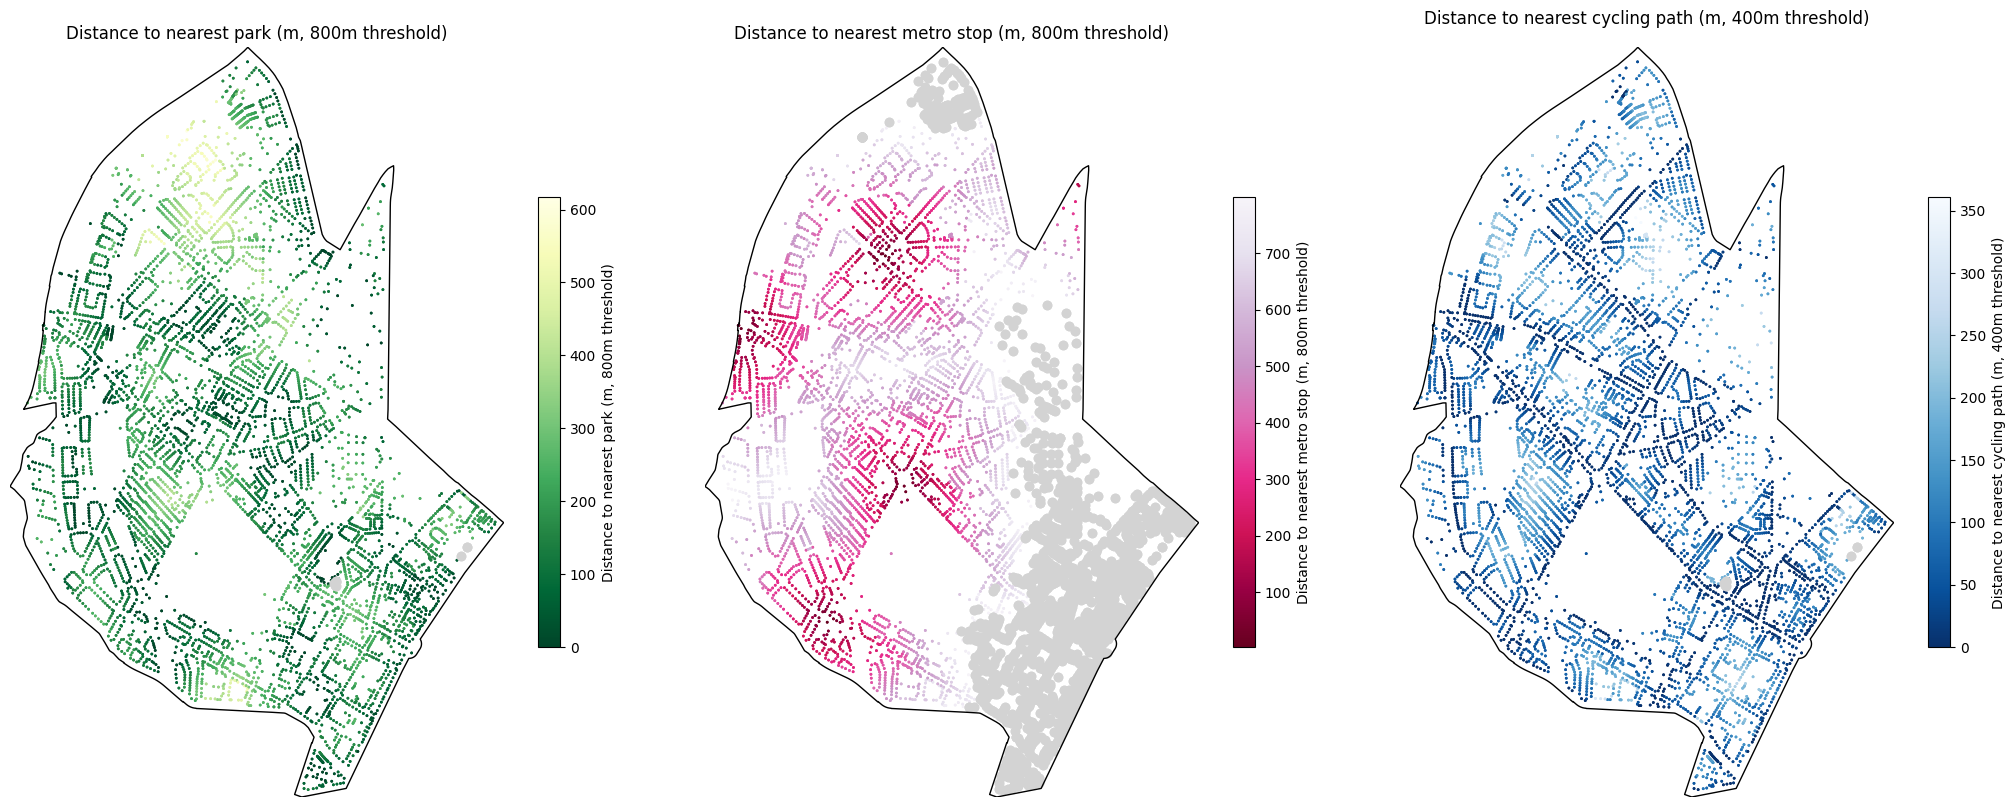

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

plot_cfg = [
    (
        "cc_park_nearest_max_800",
        "Distance to nearest park (m, 800m threshold)",
        "YlGn_r",
    ),
    (
        "cc_metro_nearest_max_800",
        "Distance to nearest metro stop (m, 800m threshold)",
        "PuRd_r",
    ),
    (
        "cc_cycling_infra_nearest_max_400",
        "Distance to nearest cycling path (m, 400m threshold)",
        "Blues_r",
    ),
]

for ax, (col, title, cmap) in zip(axes, plot_cfg):
    if col not in gdf_access.columns:
        ax.set_title(f"{col}\n(not available)")
        continue
    gdf_access.plot(
        column=col,
        cmap=cmap,
        legend=True,
        legend_kwds={"label": title, "shrink": 0.6},
        missing_kwds={"color": "lightgrey", "label": "No POI in range"},
        markersize=1,
        ax=ax,
    )
    boundary.boundary.plot(ax=ax, color="black", linewidth=1)
    ax.set_xlim(bbox[0], bbox[2])
    ax.set_ylim(bbox[1], bbox[3])
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.show()

Buildings with known building_id: 2,127
Population-weighted mean distance to nearest park (800m threshold)
neighbourhood_name
Mimersgade-kvarteret     112.4
Guldbergskvarteret       125.8
Blagardskvarteret        127.8
Stefansgade              132.3
Haraldsgade-kvarteret    282.0


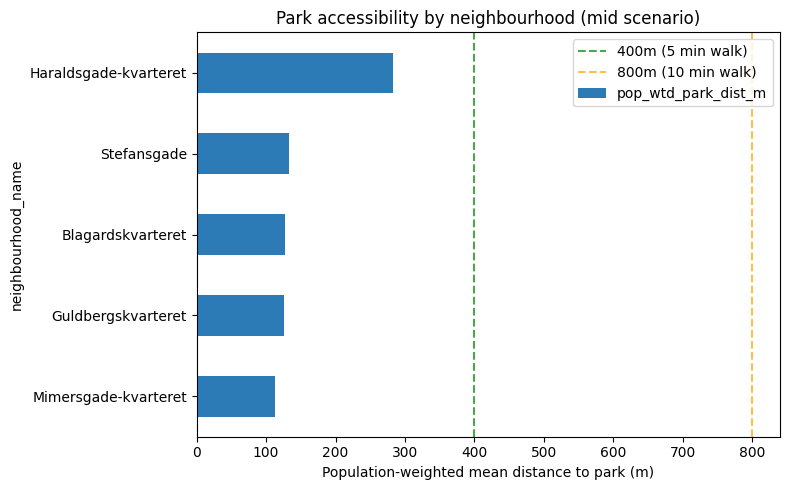

In [23]:
# Population-weighted mean distance to nearest park per neighbourhood.
#
# Each building's population is counted ONCE, using the entrance that is closest
# to the park (min distance across all entrances of that building).
# This matches the "best exit" assumption: residents choose whichever entrance
# minimises their walk to the destination.
if (
    "cc_park_nearest_max_800" in gdf_access.columns
    and "neighbourhood_name" in gdf_access.columns
):
    # Collapse to best entrance per building (min distance wins)
    gdf_building_best = (
        gdf_access.dropna(
            subset=["building_id"]
        )  # exclude unmatched / synthetic-only entrances
        .sort_values("cc_park_nearest_max_800", na_position="last")
        .drop_duplicates(subset=["building_id"], keep="first")
    )
    gdf_building_best = gdf_building_best.copy()
    gdf_building_best["pop_total_mid"] = gdf_building_best[
        [
            c
            for c in gdf_building_best.columns
            if c.endswith("_mid") and c.startswith("pop_")
        ]
    ].sum(axis=1)

    print(f"Buildings with known building_id: {len(gdf_building_best):,}")

    summary = (
        gdf_building_best.groupby("neighbourhood_name")
        .apply(
            lambda g: np.average(
                g["cc_park_nearest_max_800"].fillna(800),  # cap unmatched at threshold
                weights=g["pop_total_mid"].fillna(0).clip(lower=0) + 1e-6,
            ),
            include_groups=False,
        )
        .rename("pop_wtd_park_dist_m")
        .sort_values()
    )

    print("Population-weighted mean distance to nearest park (800m threshold)")
    print(summary.round(1).to_string())

    fig, ax = plt.subplots(figsize=(8, 5))
    summary.sort_values().plot(kind="barh", ax=ax, color="#2c7bb6")
    ax.set_xlabel("Population-weighted mean distance to park (m)")
    ax.set_title("Park accessibility by neighbourhood (mid scenario)")
    ax.axvline(400, color="green", linestyle="--", alpha=0.7, label="400m (5 min walk)")
    ax.axvline(
        800, color="orange", linestyle="--", alpha=0.7, label="800m (10 min walk)"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Write Output

Append `entrances_accessibility` layer to the integrated buildings GeoPackage.

In [ ]:
# Drop pop_total_mid helper column before writing (already in entrances_demographics)
gdf_out = gdf_access.drop(columns=["pop_total_mid"], errors="ignore")

print(f"Writing layer '{ENTRANCES_ACCESSIBILITY_LAYER}' to {INTEGRATED_BUILDINGS}")
print(f"  Rows: {len(gdf_out):,}")
print(f"  Columns: {len(gdf_out.columns)} ({len(metric_cols)} new cc_* columns)")

gdf_out.to_file(INTEGRATED_BUILDINGS, layer=ENTRANCES_ACCESSIBILITY_LAYER, driver="GPKG")

size_mb = INTEGRATED_BUILDINGS.stat().st_size / 1_000_000
print(f"\nDone — GeoPackage size: {size_mb:.1f} MB")
print(f"New metric columns: {metric_cols}")